In [ ]:
from __future__ import annotations
import random
import csv
import re
import unicodedata
import warnings
from pathlib import Path
from typing import List

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import rand
import pandas as pd
from shapely import box, wkt
from shapely.ops import unary_union
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

random.seed(33)

In [ ]:
ROOT = Path("/Users/ivanr/Developer/ai-vineyard-productivity")
DATA_DIR = ROOT / "data" / "raw-excels"
OUT_DIR = ROOT / "data" / "datasets" / "raw"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "innovi": {
        "book": DATA_DIR / "Viñedos_Innovi_corrected (1).xlsx",
        "sigpac": DATA_DIR / "Viñedos_Innovi_corrected_sigpac (1).xlsx",
    },
    "tactic": {
        "book": DATA_DIR / "Tactic_plantilla_viñedo_CWP_corrected (1).xlsx",
        "sigpac": DATA_DIR / "Tactic_plantilla_viñedo_CWP_corrected_sigpac (1).xlsx",
    },
}

FULL_AOI = Path(
    "/Users/ivanr/Developer/ai-vineyard-productivity/data/raw-excels/Full_aoi_table.xlsx"
)

# SIGPAC CRS for Catalonia: ETRS89 / UTM zone 31N
SRC_EPSG = 25831
DST_EPSG = 3857

# SIGPAC join keys
KEY_PARCELA = ["provincia", "municipio", "agregado", "zona", "poligono", "parcela"]
KEY_RECINTO = KEY_PARCELA + ["recinto"]

for k, v in FILES.items():
    print(f"{k}: book={v['book'].exists()}, sigpac={v['sigpac'].exists()}")

innovi: book=True, sigpac=True
tactic: book=True, sigpac=True


## Helper functions


In [ ]:
column_map_en = {
    "id_lugar": "place_id",
    "fecha_inicio_cosecha": "harvest_start_date",
    "fecha_fin_cosecha": "harvest_date",
    "produccion_kg": "production_kg",
    "grado_alcoholico": "alcohol_degree",
    "tipo_de_certificacion_manejo": "certification",
    "variedad_comercial_principal": "variety",
    "secano": "dry_farming",
}
cols_to_drop = [
    "densidad_plantacion_arboles_ha",
    "sistema_de_conduccion",
    "producto",
    "fecha_de_plantacion",
    "portainjerto",
    "marco_plantacion_mxm",
    "cultivo",
    "fecha_inicio_cosecha",
]
dtype_map = {
    "place_id": str,
    "harvest_date": "datetime64[ns]",
    "production_kg": int,
    "alcohol_degree": float,
    "certification": "category",
    "variety": "category",
    "dry_farming": "category",
}

In [ ]:
def normalize_col(col: str) -> str:
    """Normalize column name: lowercase, ASCII, underscored."""
    col = str(col).strip().lower()
    col = unicodedata.normalize("NFKD", col).encode("ascii", "ignore").decode("ascii")
    col = re.sub(r"[^a-z0-9]+", "_", col)
    return re.sub(r"_+", "_", col).strip("_")


def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Apply normalize_col to all column names."""
    out = df.copy()
    out.columns = [normalize_col(c) for c in out.columns]
    return out

## Load excels


In [ ]:
def load_all_sheets(filepath: Path) -> dict[str, pd.DataFrame]:
    """Load every sheet from an Excel file with normalized column names."""
    xls = pd.ExcelFile(filepath)
    return {
        normalize_col(s): clean_columns(pd.read_excel(filepath, sheet_name=s))
        for s in xls.sheet_names
    }


sheets = {}
for source, paths in FILES.items():
    book = load_all_sheets(paths["book"])
    sig = load_all_sheets(paths["sigpac"])
    sheets[source] = {"book": book, "sigpac": sig}

    print(f"\n--- {source.upper()} ---")
    for section in ("book", "sigpac"):
        for name, df in sheets[source][section].items():
            print(f"  [{section}] {name}: {df.shape}")


aoi_df = load_all_sheets(FULL_AOI)["sheet_1"]


--- INNOVI ---
  [book] id_lugar: (8341, 13)
  [book] finca_vinedo: (5262, 11)
  [book] produccion: (21388, 15)
  [book] fenologia: (772, 1)
  [book] fitosanitarios: (10742, 8)
  [book] fertilizantes: (1978, 14)
  [book] series_temporales: (27, 7)
  [sigpac] parcelas_sigpac: (3498, 7)
  [sigpac] recintos_sigpac: (7651, 8)

--- TACTIC ---
  [book] id_lugar: (15, 13)
  [book] finca_vinedo: (7, 11)
  [book] produccion: (35, 15)
  [book] fitosanitarios: (87, 8)
  [book] fertilizantes: (28, 14)
  [sigpac] parcelas_sigpac: (3, 7)
  [sigpac] recintos_sigpac: (15, 8)


In [ ]:
raw_tactic = sheets["tactic"]["book"]["produccion"]
raw_innovi = sheets["innovi"]["book"]["produccion"]

## Merge and clean data

In [ ]:
def merge_sheets(base: pd.DataFrame, book: dict[str, pd.DataFrame]) -> pd.DataFrame:
    for name, df in book.items():
        if name in ["finca_vinedo"]:
            cols = [c for c in df.columns if c != "id_lugar"]
            base = base.merge(df[["id_lugar"] + cols], on="id_lugar", how="left")

    return base


def clean_produccion(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna(axis=1, how="all")
    if "destino_del_cultivo" in df.columns:
        df = df.drop(columns=["destino_del_cultivo"])

    return df


def normalize_place_id(place_id: str) -> List[str]:
    ids = [x.strip() for x in place_id.split(",")]
    ids = sorted(ids)
    return ",".join(ids)


def aggregate_duplicates_same_period(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.assign(place_id_norm=df["place_id"].apply(normalize_place_id))
        .assign(year=df["harvest_date"].apply(lambda x: x.year))
        .groupby(["place_id_norm", "year"], as_index=False)
        .agg(
            {
                "production_kg": "sum",
                "alcohol_degree": "mean",
                "harvest_date": lambda x: df.loc[x.index, "harvest_date"].loc[
                    df.loc[x.index, "production_kg"].idxmax()
                ],
            }
        )
    ).rename(columns={"place_id_norm": "place_id"})


# Agrupar localizaciones
def aggregate_places_df(ref_df: pd.DataFrame, places_df: pd.DataFrame) -> pd.DataFrame:
    geo_cols = ["provincia", "municipio", "poligono", "parcela", "recinto"]
    rows = []

    for place_id_str in ref_df["place_id"].unique():
        ids = [x.strip() for x in place_id_str.split(",")]

        subset = places_df[places_df["id_lugar"].isin(ids)]

        superficie = subset["superficie_ha"].sum()

        geo_data = {col: subset[col].astype(str).tolist() for col in geo_cols}

        rows.append({"place_id": place_id_str, "superficie_ha": superficie, **geo_data})

    return ref_df.merge(pd.DataFrame(rows), on="place_id", how="left")


def assign_geometry(ref_df: pd.DataFrame, aoi_df: pd.DataFrame) -> pd.DataFrame:
    """
    For each row in ref_df, look up matching rows in aoi_df using
    (provincia, municipio, poligono, parcela, recinto) and merge their geometries.
    """
    # Build a lookup index on aoi_df keyed by (prov, mun, pol, par, rec)
    aoi_lookup = {}
    for idx, row in aoi_df.iterrows():
        key = (
            row["provincia"],
            row["municipio"],
            row["poligono"],
            row["parcela"],
            row["recinto"],
        )
        # print(key)
        aoi_lookup.setdefault(key, []).append(row["geometry"])
    # print("----")
    geometries = []
    for _, row in ref_df.iterrows():
        geoms = []
        for prov, mun, pol, par, rec in zip(
            row["provincia"],
            row["municipio"],
            row["poligono"],
            row["parcela"],
            row["recinto"],
        ):
            key = (int(prov), int(mun), int(pol), int(par), int(rec))
            # print(key)
            if key in aoi_lookup:
                geoms.extend(aoi_lookup[key])

        if geoms:
            parsed = [wkt.loads(g) if isinstance(g, str) else g for g in geoms]
            geometries.append(unary_union(parsed))
        else:
            geometries.append(None)

    ref_df = ref_df.copy()
    ref_df["geometry"] = geometries
    return ref_df


def clean_location_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Count recintos
    df["total_recintos"] = df["recinto"].apply(len)

    # Deduplicate lists where all values are the same
    for col in ["provincia", "municipio", "poligono", "parcela", "recinto"]:
        df[col] = df[col].apply(lambda x: [x[0]] if len(set(x)) == 1 else x)

    return df


def compute_spatial_features(
    df: pd.DataFrame,
    crs: str = "EPSG:3857",
    area_crs: str = "EPSG:25831",
) -> gpd.GeoDataFrame:
    gdf = gpd.GeoDataFrame(df, geometry="geometry")

    # Assign CRS without reprojecting (we're telling geopandas what it already is)
    if gdf.crs is None:
        gdf = gdf.set_crs(crs)

    gdf["area_ha"] = gdf.geometry.to_crs(area_crs).area / 10_000

    gdf["yield_kg_ha"] = gdf["production_kg"] / gdf["area_ha"]

    return gdf.round(2)


def rename_and_order_columns(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gdf.rename(
        columns={
            "place_id": "parcel_id",
            "superficie_ha": "declared_area_ha",
            "provincia": "province",
            "municipio": "municipality",
            "poligono": "polygon",
            "parcela": "parcel",
            "recinto": "enclosure",
            "total_recintos": "total_enclosures",
        }
    )

    column_order = [
        "parcel_id",
        "year",
        "harvest_date",
        "province",
        "municipality",
        "polygon",
        "parcel",
        "enclosure",
        "total_enclosures",
        "declared_area_ha",
        "area_ha",
        "production_kg",
        "yield_kg_ha",
        "alcohol_degree",
        "geometry",
    ]

    return gdf[column_order]


def add_bbox_geometry(
    gdf: gpd.GeoDataFrame,
    margin: float,
    source_col: str = "geometry",
    new_col: str = "geometry",
    renamed_col: str = "parcel_geometry",
    target_crs: str = None,
) -> gpd.GeoDataFrame:
    gdf = gdf.copy()

    # 1. Rename original geometry
    gdf = gdf.rename(columns={source_col: renamed_col})

    # 2. Create bbox geometry
    def make_bbox(geom):
        if geom is None or geom.is_empty:
            return None
        minx, miny, maxx, maxy = geom.bounds
        return box(minx - margin, miny - margin, maxx + margin, maxy + margin)

    gdf[new_col] = gdf[renamed_col].apply(make_bbox)

    # 3. Set geometry column
    gdf = gdf.set_geometry(new_col)

    # 4. Set / convert CRS if provided
    if target_crs:
        gdf = gdf.set_crs(target_crs, allow_override=True)

    return gdf


def remove_errors(
    gdf: gpd.GeoDataFrame,
    area_diff_threshold_pct: float = 20.0,
    yield_quantile_low: float = 0.01,
    yield_quantile_high: float = 0.99,
) -> gpd.GeoDataFrame:
    """
    Remove geometrically inconsistent and yield-outlier parcels from the full dataset.
    Should be applied BEFORE train/test split.

    Args:
        gdf: Full GeoDataFrame with area_ha, declared_area_ha, yield_kg_ha already computed.
        area_diff_threshold_pct: Max allowed % deviation between computed and declared area.
        yield_quantile_low: Lower quantile cutoff for yield outlier removal.
        yield_quantile_high: Upper quantile cutoff for yield outlier removal.

    Returns:
        Cleaned GeoDataFrame with a diagnostic report printed.
    """
    n_original = len(gdf)

    # Stage 1 — bad geometries
    area_diff_pct = (
        (gdf["area_ha"] - gdf["declared_area_ha"]) / gdf["declared_area_ha"]
    ) * 100
    geo_mask = area_diff_pct.abs() <= area_diff_threshold_pct
    gdf = gdf[geo_mask].copy()
    n_after_geo = len(gdf)

    # Stage 2 — yield outliers (computed on already-clean data)
    low, high = gdf["yield_kg_ha"].quantile([yield_quantile_low, yield_quantile_high])
    yield_mask = gdf["yield_kg_ha"].between(low, high)
    gdf = gdf[yield_mask].copy()
    n_after_yield = len(gdf)

    # Report
    print(f"Original rows:         {n_original:>7}")
    print(
        f"After geometry filter: {n_after_geo:>7}  (removed {n_original - n_after_geo}, {100 * (n_original - n_after_geo) / n_original:.1f}%)"
    )
    print(
        f"After yield filter:    {n_after_yield:>7}  (removed {n_after_geo - n_after_yield}, {100 * (n_after_geo - n_after_yield) / n_after_geo:.1f}%)"
    )
    print(
        f"Total removed:         {n_original - n_after_yield:>7}  ({100 * (n_original - n_after_yield) / n_original:.1f}%)"
    )
    print(f"Yield range kept:      [{low:.1f}, {high:.1f}] kg/ha")

    return gdf

In [ ]:
# Innovi
produccion_innovi = clean_produccion(sheets["innovi"]["book"]["produccion"])
innovi_df = merge_sheets(produccion_innovi, sheets["innovi"]["book"])
innovi_df = innovi_df.drop(columns=cols_to_drop)
innovi_df = innovi_df.rename(columns=column_map_en)
innovi_df = innovi_df.astype(dtype_map, errors="ignore")
innovi_df = aggregate_duplicates_same_period(
    innovi_df
)  # Producciones de la misma finca el mismo año agrupar producciones
innovi_df = aggregate_places_df(innovi_df, sheets["innovi"]["book"]["id_lugar"])
innovi_df = assign_geometry(innovi_df, aoi_df)
innovi_df = clean_location_columns(innovi_df)
innovi_df = compute_spatial_features(innovi_df)
innovi_df = rename_and_order_columns(innovi_df)
final_innovi_df = innovi_df[innovi_df.geometry.notnull()]
final_innovi_df = add_bbox_geometry(final_innovi_df, margin=500, target_crs="EPSG:3857")
final_innovi_df = remove_errors(final_innovi_df)

print(final_innovi_df.shape)
print(final_innovi_df.head(1))

# Tactic
produccion_tactic = clean_produccion(sheets["tactic"]["book"]["produccion"])
tactic_df = merge_sheets(produccion_tactic, sheets["innovi"]["book"])
tactic_df = tactic_df.drop(columns=cols_to_drop)
tactic_df = tactic_df.rename(columns=column_map_en)
tactic_df = tactic_df.astype(dtype_map, errors="ignore")
tactic_df = aggregate_duplicates_same_period(
    tactic_df
)  # Producciones de la misma finca el mismo año agrupar producciones
tactic_df = aggregate_places_df(tactic_df, sheets["tactic"]["book"]["id_lugar"])  #
tactic_df = assign_geometry(tactic_df, aoi_df)
tactic_df = clean_location_columns(tactic_df)
tactic_df = compute_spatial_features(tactic_df)
tactic_df = rename_and_order_columns(tactic_df)
final_tactic_df = tactic_df[tactic_df.geometry.notnull()]
final_tactic_df = add_bbox_geometry(final_tactic_df, margin=500, target_crs="EPSG:3857")


# print(tactic_df.shape)
# print(tactic_df.head(1))

Original rows:           11970
After geometry filter:   11708  (removed 262, 2.2%)
After yield filter:      11472  (removed 236, 2.0%)
Total removed:             498  (4.2%)
Yield range kept:      [557.9, 42998.4] kg/ha
(11472, 16)
    parcel_id  year harvest_date province municipality polygon parcel enclosure  total_enclosures  declared_area_ha  area_ha  production_kg  yield_kg_ha  alcohol_degree  \
0  L1100,L194  2021   2021-09-22      [8]         [13]     [4]   [49]   [6, 10]                 2              1.19     1.19           6734      5656.27            11.4   

                                     parcel_geometry                                           geometry  
0  MULTIPOLYGON (((197985.277 5068113.845, 197898...  POLYGON ((198537.602 5067605.265, 198537.602 5...  


In [60]:
def export_to_csv(gdf: gpd.GeoDataFrame, path: str) -> None:
    df = gdf.copy()
    # Ensure list columns have consistent int values
    try:
        list_cols = ["province", "municipality", "polygon", "parcel", "enclosure"]
        for col in list_cols:
            df[col] = df[col].apply(
                lambda x: [int(v) for v in x] if isinstance(x, list) else x
            )
            df[col] = df[col].apply(str)
    except KeyError:
        pass

    df.to_csv(path, index=False, quoting=csv.QUOTE_NONNUMERIC)


export_to_csv(final_innovi_df, OUT_DIR / "innovi_dataset_processed.csv")
export_to_csv(final_innovi_df, OUT_DIR / "tactic_dataset_processed.csv")

# Particiones

In [70]:
df = final_innovi_df.copy()

test_df = df[df.year == 2025].copy()
val_df = df[df.year == 2024].copy()
train_df = df[(df.year < 2024)].copy()


# Add split labels
train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

df_all = pd.concat([train_df, val_df, test_df])

# ----

# Sample 1000 unique parcels
unique_parcels = df_all['parcel_id'].unique()
sampled_parcels = pd.Series(unique_parcels).sample(n=1000, random_state=42).values

# Filter both datasets to only sampled parcels
df_sampled = df_all[df_all['parcel_id'].isin(sampled_parcels)].copy()

df_parcels_sampled = (
    df_sampled
    .drop_duplicates(subset="parcel_id")
    [["parcel_id", "enclosure", "parcel_geometry", "geometry"]]
    .reset_index(drop=True)
)

# Export
export_to_csv(df_sampled, OUT_DIR / "SAMPLED_SPLITS_DATASET.csv")
export_to_csv(df_parcels_sampled, OUT_DIR / "SAMPLED_AOI_DATASET.csv")

print(f"Sampled parcels: {len(df_parcels_sampled)}")
print(df_sampled.groupby('split')['parcel_id'].nunique().rename('unique_parcels'))



df_all = df_sampled.copy()
# export_to_csv(df_all, OUT_DIR / "FULL_SPLITS_DATASET.csv")

# df_parcels = (
#     df_all
#     .drop_duplicates(subset="parcel_id")
#     [["parcel_id", "enclosure", "parcel_geometry", "geometry"]]
#     .reset_index(drop=True)
# )

# print(f"Unique parcels: {len(df_parcels)}")
# export_to_csv(df_parcels, OUT_DIR / "FULL_AOI_DATASET.csv")


Sampled parcels: 1000
split
test     546
train    879
val      609
Name: unique_parcels, dtype: int64


In [71]:
summary = df_all.groupby("year").agg(
    n_rows         = ("parcel_id", "count"),
    unique_parcels = ("parcel_id", "nunique"),
    total_area_ha  = ("area_ha", "sum"),
    mean_area_ha   = ("area_ha", "mean"),
    total_prod_t   = ("production_kg", lambda x: x.sum() / 1_000),
    mean_yield     = ("yield_kg_ha", "mean"),
    median_yield   = ("yield_kg_ha", "median"),
    std_yield      = ("yield_kg_ha", "std"),
    mean_alcohol   = ("alcohol_degree", "mean"),
).round(2)

# Totals row — unique parcels across the full dataset
totals = pd.Series({
    "n_rows":         df_all.shape[0],
    "unique_parcels": df_all["parcel_id"].nunique(),  # ← not sum, real unique count
    "total_area_ha":  df_all["area_ha"].sum().round(2),
    "mean_area_ha":   df_all["area_ha"].mean().round(2),
    "total_prod_t":   (df_all["production_kg"].sum() / 1_000).round(2),
    "mean_yield":     df_all["yield_kg_ha"].mean().round(2),
    "median_yield":   df_all["yield_kg_ha"].median().round(2),
    "std_yield":      df_all["yield_kg_ha"].std().round(2),
    "mean_alcohol":   df_all["alcohol_degree"].mean().round(2),
}, name="TOTAL")

summary = pd.concat([summary, totals.to_frame().T])
summary.index.name = "year"
summary.columns = [
    "Rows", "Unique parcels", "Total area (ha)", "Mean area (ha)",
    "Total prod (t)", "Mean yield (kg/ha)", "Median yield (kg/ha)",
    "Std yield (kg/ha)", "Mean alcohol (°)"
]

print(summary.to_string())

         Rows  Unique parcels  Total area (ha)  Mean area (ha)  Total prod (t)  Mean yield (kg/ha)  Median yield (kg/ha)  Std yield (kg/ha)  Mean alcohol (°)
year                                                                                                                                                         
2020    196.0           196.0           135.16            0.69         1120.87             9829.43               8122.14            7530.62             14.28
2021    618.0           618.0           473.98            0.77         4439.99            10507.33               9218.64            6670.52             12.03
2022    634.0           634.0           470.55            0.74         3871.43             9709.17               8441.56            6699.81             12.37
2023    717.0           717.0           494.21            0.69         3347.86             7130.14               7013.13            3919.13             12.34
2024    609.0           609.0           442.86      

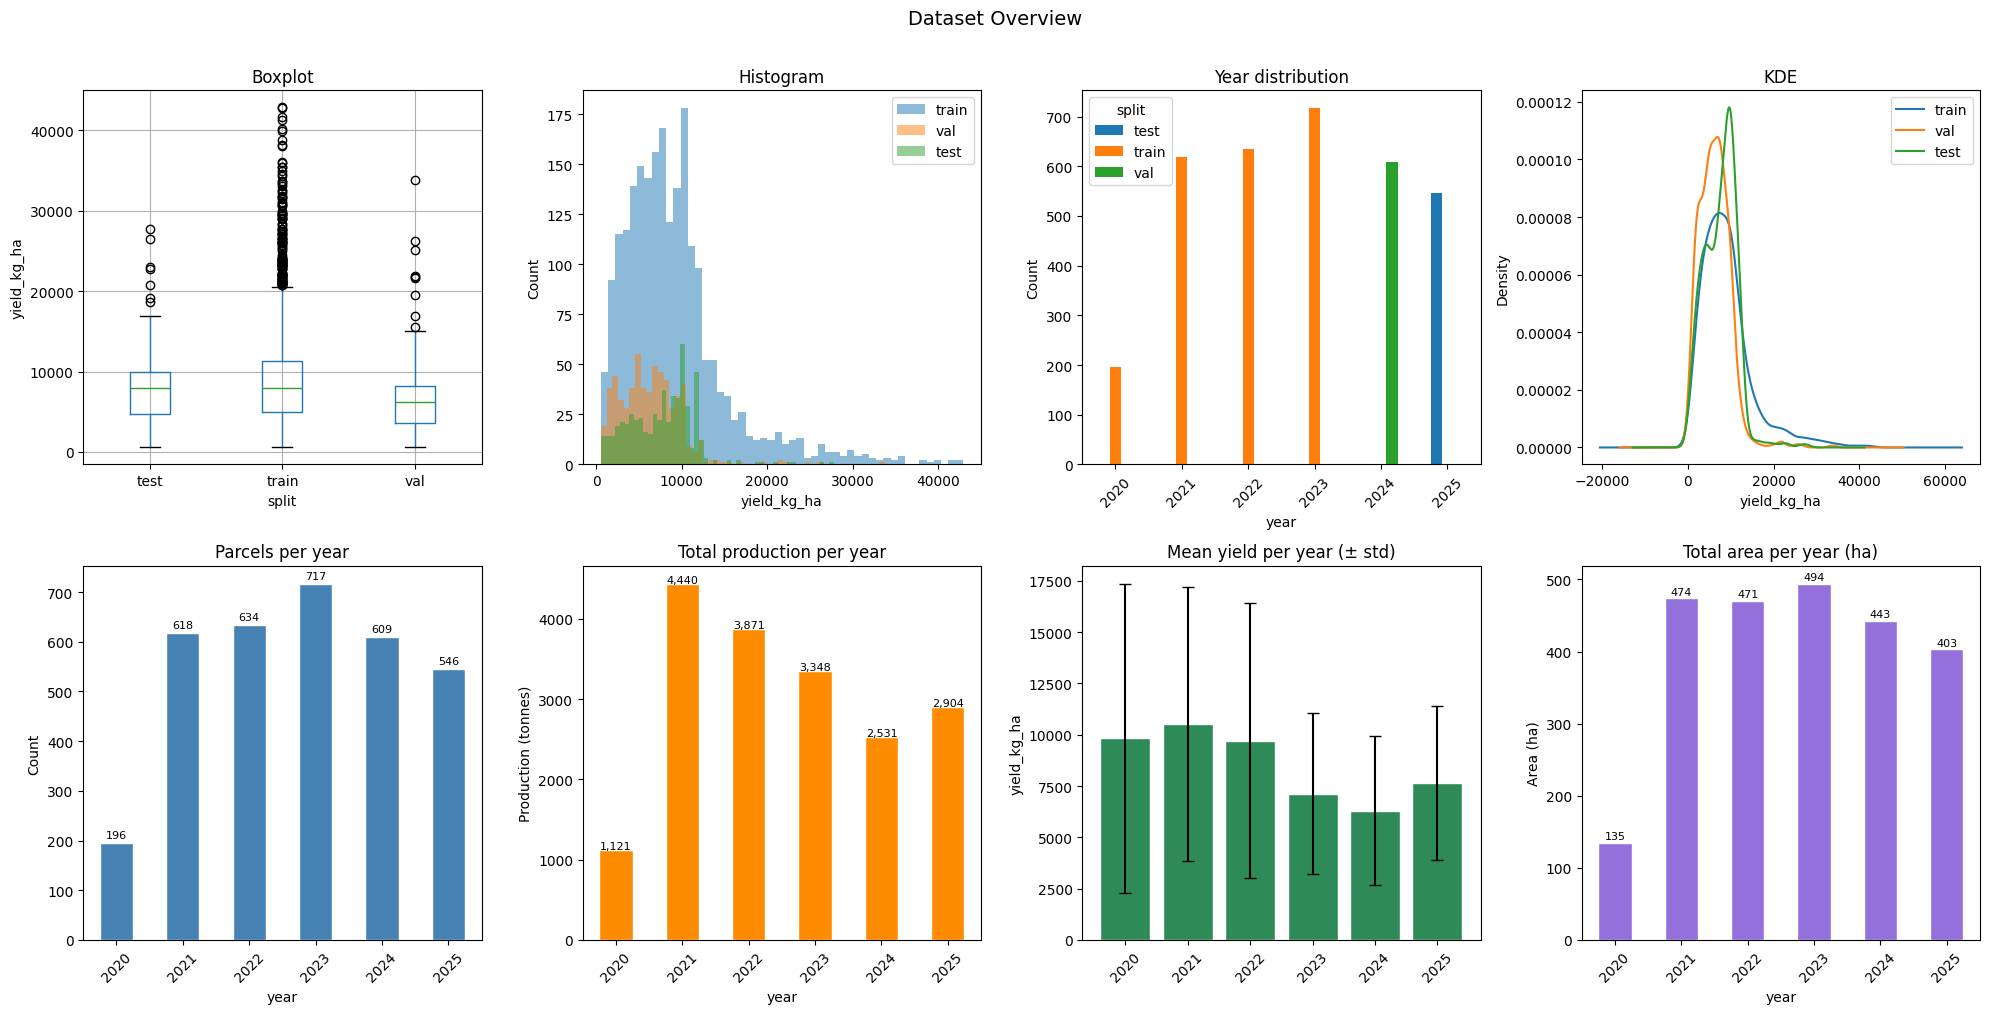

In [72]:
# Distribución de los datasets
feature = "yield_kg_ha"

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# ── ROW 1: yield distribution ──────────────────────────────────────────────

# 1. Boxplot
df_all.boxplot(column=feature, by="split", ax=axes[0, 0])
axes[0, 0].set_title("Boxplot")
axes[0, 0].set_ylabel(feature)

# 2. Histogram
for split in ["train", "val", "test"]:
    subset = df_all[df_all["split"] == split]
    axes[0, 1].hist(subset[feature], bins=50, alpha=0.5, label=split)
axes[0, 1].set_title("Histogram")
axes[0, 1].set_xlabel(feature)
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

# 3. Year distribution (parcel count)
pd.crosstab(df_all["year"], df_all["split"]).plot(kind="bar", ax=axes[0, 2])
axes[0, 2].set_title("Year distribution")
axes[0, 2].set_ylabel("Count")
axes[0, 2].tick_params(axis="x", rotation=45)

# 4. KDE
for split in ["train", "val", "test"]:
    subset = df_all[df_all["split"] == split]
    subset[feature].plot(kind="kde", ax=axes[0, 3], label=split)
axes[0, 3].set_title("KDE")
axes[0, 3].set_xlabel(feature)
axes[0, 3].legend()

# ── ROW 2: year-level statistics ───────────────────────────────────────────

# 5. Parcel count per year
year_counts = df_all.groupby("year").size()
year_counts.plot(kind="bar", ax=axes[1, 0], color="steelblue", edgecolor="white")
axes[1, 0].set_title("Parcels per year")
axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis="x", rotation=45)
for i, v in enumerate(year_counts):
    axes[1, 0].text(i, v + 10, str(v), ha="center", fontsize=8)

# 6. Total production per year (kg)
year_production = df_all.groupby("year")["production_kg"].sum() / 1_000  # tonnes
year_production.plot(kind="bar", ax=axes[1, 1], color="darkorange", edgecolor="white")
axes[1, 1].set_title("Total production per year")
axes[1, 1].set_ylabel("Production (tonnes)")
axes[1, 1].tick_params(axis="x", rotation=45)
for i, v in enumerate(year_production):
    axes[1, 1].text(i, v + 10, f"{v:,.0f}", ha="center", fontsize=8)

# 7. Mean yield per year with std band
year_yield = df_all.groupby("year")["yield_kg_ha"].agg(["mean", "std"])
axes[1, 2].bar(year_yield.index, year_yield["mean"], color="seagreen", edgecolor="white")
axes[1, 2].errorbar(
    year_yield.index, year_yield["mean"],
    yerr=year_yield["std"], fmt="none", color="black", capsize=4
)
axes[1, 2].set_title("Mean yield per year (± std)")
axes[1, 2].set_ylabel("yield_kg_ha")
axes[1, 2].tick_params(axis="x", rotation=45)

# 8. Total area per year
year_area = df_all.groupby("year")["area_ha"].sum()
year_area.plot(kind="bar", ax=axes[1, 3], color="mediumpurple", edgecolor="white")
axes[1, 3].set_title("Total area per year (ha)")
axes[1, 3].set_ylabel("Area (ha)")
axes[1, 3].tick_params(axis="x", rotation=45)
for i, v in enumerate(year_area):
    axes[1, 3].text(i, v + 5, f"{v:,.0f}", ha="center", fontsize=8)

plt.suptitle("Dataset Overview", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Diferencia de areas

count    7458.000000
mean       -0.286121
std         1.984256
min       -19.047619
1%        -12.068966
5%         -0.831025
50%         0.000000
95%         0.000000
99%         1.851852
max        18.518519
Name: area_diff_pct, dtype: float64
Suspicious parcels: 0 / 7458 (0.0%)


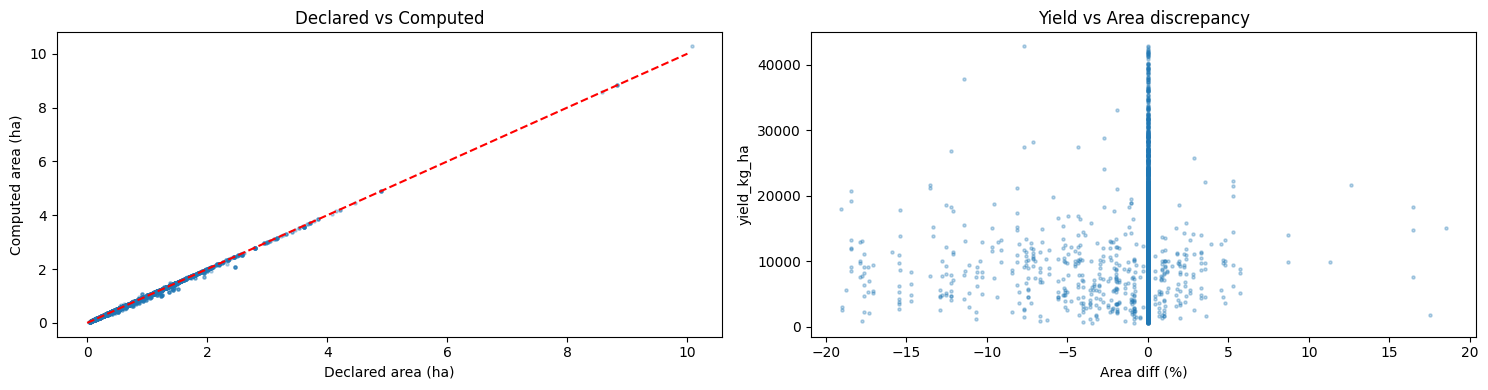

In [45]:
# Area discrepancy analysis
train_df["area_diff_ha"] = train_df["area_ha"] - train_df["declared_area_ha"]
train_df["area_diff_pct"] = (
    train_df["area_diff_ha"] / train_df["declared_area_ha"]
) * 100

print(train_df["area_diff_pct"].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

# Parcels where computed area deviates >20% from declared
suspicious = train_df[train_df["area_diff_pct"].abs() > 20].sort_values("area_diff_pct")

print(
    f"Suspicious parcels: {len(suspicious)} / {len(train_df)} ({100 * len(suspicious) / len(train_df):.1f}%)"
)
suspicious[
    ["parcel_id", "declared_area_ha", "area_ha", "area_diff_pct", "yield_kg_ha"]
].head(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 1. Scatter: declared vs computed
axes[0].scatter(train_df["declared_area_ha"], train_df["area_ha"], alpha=0.3, s=5)
axes[0].plot([0, 10], [0, 10], "r--")  # perfect agreement line
axes[0].set(
    xlabel="Declared area (ha)",
    ylabel="Computed area (ha)",
    title="Declared vs Computed",
)

# 3. yield vs area diff — wrongly drawn polygons will cluster here
axes[1].scatter(
    train_df["area_diff_pct"].clip(-100, 200),
    train_df["yield_kg_ha"].clip(0, 50_000),
    alpha=0.3,
    s=5,
)
axes[1].set(
    xlabel="Area diff (%)", ylabel="yield_kg_ha", title="Yield vs Area discrepancy"
)

plt.tight_layout()
plt.show()

### Valores excesivos de yield_kg_ha?

In [15]:
train_df["yield_kg_ha"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count     7458.000000
mean      9210.801213
std       6325.684449
min        560.880000
1%         972.990900
5%        2014.719000
50%       7999.160000
95%      21860.947500
99%      33594.109400
max      42875.580000
Name: yield_kg_ha, dtype: float64

In [16]:
train_df[train_df.yield_kg_ha > 30000]


,parcel_id,year,harvest_date,province,municipality,polygon,parcel,enclosure,total_enclosures,declared_area_ha,area_ha,production_kg,yield_kg_ha,alcohol_degree,parcel_geometry,geometry,split,area_diff_ha,area_diff_pct
433,L3233,2020,2020-09-24,[43],[22],[2],[177],[1],1,0.19,0.19,6080,31521.40,16.80,"POLYGON ((37331.513 5022201.924, 37330.697 502...","POLYGON ((37853.963 5021701.924, 37853.963 502...",train,0.00,0.000000
434,L3233,2021,2021-09-18,[43],[22],[2],[177],[1],1,0.19,0.19,6270,32506.45,13.05,"POLYGON ((37331.513 5022201.924, 37330.697 502...","POLYGON ((37853.963 5021701.924, 37853.963 502...",train,0.00,0.000000
445,L3236,2020,2020-09-18,[43],[22],[39],[185],[28],1,0.18,0.18,6235,33921.01,16.80,"POLYGON ((32500.424 5021862.376, 32519.827 502...","POLYGON ((33086.8 5021317.79, 33086.8 5022365....",train,0.00,0.000000
450,L3237,2022,2022-09-05,[43],[22],[39],[185],[3],1,0.18,0.18,7650,42018.37,14.50,"POLYGON ((32567.476 5021681.078, 32563.034 502...","POLYGON ((33107.682 5021181.078, 33107.682 502...",train,0.00,0.000000
470,L3243,2020,2020-09-25,[43],[22],[42],[253],[7],1,0.34,0.34,11190,32593.64,15.00,"POLYGON ((34548.314 5022466.751, 34516.644 502...","POLYGON ((35126.876 5021966.751, 35126.876 502...",train,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11523,L6731,2022,2022-08-24,[43],[22],[42],[249],[7],1,0.11,0.11,3240,30552.80,12.50,"POLYGON ((34662.516 5021988.656, 34650.292 502...","POLYGON ((35224.006 5021488.656, 35224.006 502...",train,0.00,0.000000
11619,L6785,2020,2020-09-28,[43],[22],[43],[48],[12],1,0.21,0.21,8680,41201.64,17.00,"POLYGON ((37305.14 5021003.728, 37302.154 5021...","POLYGON ((37816.206 5020503.728, 37816.206 502...",train,0.00,0.000000
11632,L6797,2021,2021-10-14,[43],[22],[43],[50],[30],1,0.33,0.33,13586,41441.59,13.08,"POLYGON ((36873.247 5021068.036, 36868.582 502...","POLYGON ((37440.653 5020568.036, 37440.653 502...",train,0.00,0.000000
11633,L6797,2022,2022-08-31,[43],[22],[43],[50],[30],1,0.33,0.33,10551,32183.88,13.00,"POLYGON ((36873.247 5021068.036, 36868.582 502...","POLYGON ((37440.653 5020568.036, 37440.653 502...",train,0.00,0.000000


In [17]:
print((df["yield_kg_ha"] < 0).sum())  # should be 0


0


## Visualizacion Datasets

## Other

In [19]:
produccion_innovi[produccion_innovi.id_lugar == "L62196, L62198"]

,id_lugar,fecha_inicio_cosecha,fecha_fin_cosecha,produccion_kg,grado_alcoholico
9782,"L62196, L62198",2021-08-27,2021-08-27,840,12.9
10179,"L62196, L62198",2021-09-07,2021-09-07,1840,12.5
10248,"L62196, L62198",2021-09-08,2021-09-08,1538,12.6
12043,"L62196, L62198",2022-08-24,2022-08-24,1794,11.4
15867,"L62196, L62198",2023-09-11,2023-09-11,840,12.0
18628,"L62196, L62198",2025-08-22,2025-08-22,710,11.5
18656,"L62196, L62198",2025-08-23,2025-08-23,760,11.7
19347,"L62196, L62198",2025-08-30,2025-08-30,103,13.5


In [20]:
aoi_df[aoi_df.id_lugar.isin(["L62196", "L62196,L62198", "L62198"])].geometry.tolist()[1]

'POLYGON ((33614.15605046134 5031720.7630574675, 33613.334949522614 5031722.596604069, 33593.068685444116 5031760.739927518, 33590.67069747535 5031764.30780794, 33582.12387646556 5031780.152379262, 33553.59052553799 5031809.822338418, 33552.564242671506 5031824.787427334, 33588.15822190977 5031841.696239057, 33593.29486142996 5031833.533693948, 33615.80898263514 5031801.745421871, 33625.147046367696 5031784.127834359, 33637.36185590046 5031764.727762703, 33651.41014650662 5031739.2080491325, 33659.04451909826 5031728.130445795, 33660.843383302534 5031725.089440129, 33661.34752061753 5031724.237146061, 33661.98713958741 5031723.155798068, 33621.58328167979 5031706.987374397, 33614.15605046134 5031720.7630574675))'

In [ ]:
innovi_df[innovi_df.parcel_id == "L62196,L62198"][
    ["parcel_id", "harvest_date", "yield_kg_ha", "alcohol_degree", "geometry"]
]

,parcel_id,harvest_date,yield_kg_ha,alcohol_degree,geometry
6956,"L62196,L62198",2021-09-07,12404.82,12.67,"POLYGON ((33613.335 5031722.597, 33593.069 503..."
6957,"L62196,L62198",2022-08-24,5276.02,11.40,"POLYGON ((33613.335 5031722.597, 33593.069 503..."
6958,"L62196,L62198",2023-09-11,2470.38,12.00,"POLYGON ((33613.335 5031722.597, 33593.069 503..."
6959,"L62196,L62198",2025-08-23,4626.07,12.23,"POLYGON ((33613.335 5031722.597, 33593.069 503..."


### Pequeña partición para test

In [ ]:
small_train = final_innovi_df.sample(5)
export_to_csv(small_train, OUT_DIR / "aoi_small_train.csv")


In [23]:
small_train.yield_kg_ha.describe()

count        5.000000
mean      7994.360000
std       6190.964829
min       3457.510000
25%       3975.950000
50%       4521.150000
75%       9997.590000
max      18019.600000
Name: yield_kg_ha, dtype: float64

In [24]:
innovi_df[innovi_df["geometry"].isna()]

,parcel_id,year,harvest_date,province,municipality,polygon,parcel,enclosure,total_enclosures,declared_area_ha,area_ha,production_kg,yield_kg_ha,alcohol_degree,geometry
1152,L510642,2021,2021-09-06,[8],[249],[1],[2],[12],1,0.10,NaN,840,NaN,11.00,None
1153,L510642,2023,2023-09-05,[8],[249],[1],[2],[12],1,0.10,NaN,1100,NaN,10.80,None
1154,L510642,2024,2024-09-07,[8],[249],[1],[2],[12],1,0.10,NaN,740,NaN,10.00,None
1180,"L510649,L510658",2021,2021-09-03,[8],[249],[1],[2],"[52, 41]",2,0.05,NaN,1540,NaN,8.70,None
1181,"L510649,L510658",2024,2024-08-28,[8],[249],[1],[2],"[52, 41]",2,0.05,NaN,700,NaN,10.00,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10574,"L64444,L64459",2021,2021-08-31,[43],[177],[9],"[134, 158]","[19, 1]",2,1.36,NaN,14780,NaN,12.22,None
10575,"L64444,L64459",2022,2022-09-14,[43],[177],[9],"[134, 158]","[19, 1]",2,1.36,NaN,20476,NaN,13.50,None
10576,"L64444,L64459",2023,2023-08-29,[43],[177],[9],"[134, 158]","[19, 1]",2,1.36,NaN,11720,NaN,13.30,None
10577,"L64444,L64459",2024,2024-08-21,[43],[177],[9],"[134, 158]","[19, 1]",2,1.36,NaN,4760,NaN,12.20,None


In [25]:
final_innovi_df

,parcel_id,year,harvest_date,province,municipality,polygon,parcel,enclosure,total_enclosures,declared_area_ha,area_ha,production_kg,yield_kg_ha,alcohol_degree,parcel_geometry,geometry
0,"L1100,L194",2021,2021-09-22,[8],[13],[4],[49],"[6, 10]",2,1.19,1.19,6734,5656.27,11.40,"MULTIPOLYGON (((197985.277 5068113.845, 197898...","POLYGON ((198537.602 5067605.265, 198537.602 5..."
1,"L1100,L194",2022,2022-09-16,[8],[13],[4],[49],"[6, 10]",2,1.19,1.19,5350,4493.77,12.00,"MULTIPOLYGON (((197985.277 5068113.845, 197898...","POLYGON ((198537.602 5067605.265, 198537.602 5..."
2,"L1100,L194",2023,2023-09-07,[8],[13],[4],[49],"[6, 10]",2,1.19,1.19,1520,1276.74,12.00,"MULTIPOLYGON (((197985.277 5068113.845, 197898...","POLYGON ((198537.602 5067605.265, 198537.602 5..."
3,"L1100,L194",2024,2024-09-30,[8],[13],[4],[49],"[6, 10]",2,1.19,1.19,2960,2486.27,12.50,"MULTIPOLYGON (((197985.277 5068113.845, 197898...","POLYGON ((198537.602 5067605.265, 198537.602 5..."
4,L1101,2021,2021-09-06,[8],[13],[4],[50],[1],1,0.80,0.80,8810,10964.23,10.67,"POLYGON ((197818.336 5068109.654, 197795.093 5...","POLYGON ((198368.728 5067609.654, 198368.728 5..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12074,"L763,L764",2024,2024-08-29,[43],[73],[3],[40],"[32, 51]",2,0.30,0.30,771,2530.11,14.00,"MULTIPOLYGON (((84469.288 5041681.799, 84469.8...","POLYGON ((85022.138 5041081.015, 85022.138 504..."
12075,L767,2021,2021-09-08,[43],[56],[6],[167],[31],1,0.12,0.12,900,7536.81,12.50,"POLYGON ((92186.148 5037841.341, 92185.925 503...","POLYGON ((92727.045 5037341.247, 92727.045 503..."
12076,L767,2022,2022-08-31,[43],[56],[6],[167],[31],1,0.12,0.12,837,7009.24,14.00,"POLYGON ((92186.148 5037841.341, 92185.925 503...","POLYGON ((92727.045 5037341.247, 92727.045 503..."
12077,L767,2023,2023-08-30,[43],[56],[6],[167],[31],1,0.12,0.12,653,5468.38,17.00,"POLYGON ((92186.148 5037841.341, 92185.925 503...","POLYGON ((92727.045 5037341.247, 92727.045 503..."


In [ ]:
aoi_df[
    (aoi_df.provincia == 43)
    & (aoi_df.municipio == 22)
    & (aoi_df.poligono == 2)
    & (aoi_df.parcela == 18)
]

,id_lugar,provincia,municipio,agregado,zona,poligono,parcela,recinto,geometry
